#### Import the basic packages

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### Load the dataset

In [2]:
df = pd.read_csv(r"C:\Users\lrban\Desktop\BTR\DATA SCIENCE\Assignments\Logistic Regression\Titanic_train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### Basic Info gatherings

In [3]:
df.shape

(891, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df["PassengerId"].shape

(891,)

#### we can drop PassengerId later in the modelling , because it is more of a index

In [6]:
df["Cabin"].nunique()

147

In [7]:
df["cabin code"] = df["Cabin"].str[0]

#### Instead of cabin with number , for better analyzing purpose let us have a cabin code. 
#### in model training it will be helpful for naming convention like with lebel encoder

In [8]:
df = df.drop(columns = "Cabin")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,cabin code
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,NaN
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,NaN
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,NaN


In [9]:
print(f"{"Column" :<20} : {"No of unique values":<20}")
print()
for i in df.columns.tolist():
    print(f"{i:<20} : {df[i].nunique():<20}")
    

Column               : No of unique values 

PassengerId          : 891                 
Survived             : 2                   
Pclass               : 3                   
Name                 : 891                 
Sex                  : 2                   
Age                  : 88                  
SibSp                : 7                   
Parch                : 7                   
Ticket               : 681                 
Fare                 : 248                 
Embarked             : 3                   
cabin code           : 8                   


#### From the above inference we can say that apart from Age, Fare, SibSp, Parch are ratio datatype, rest all are categorical.
#### Survived and Pclass both of them are categorical datatype
#### Name and Ticket columns are Nominal Data

In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#### Converting Survived and Parch

In [11]:
df[["Survived","Pclass","PassengerId"]] = df[["Survived","Pclass","PassengerId"]].astype("category")

### Finding the Null Values

In [12]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
cabin code     687
dtype: int64

### Filling the Null Values

### Imputation
#### Age is filled with mean 
#### cabin code is filled with unknown
#### Embarked with mode

In [13]:
df["Age"].fillna(df["Age"].mean(),inplace = True)

In [14]:
df["cabin code"].fillna("unknown",inplace = True)

In [15]:
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace = True)

In [16]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
cabin code     0
dtype: int64

#### All the null values in the data set are filled.

### Finding Duplicates

In [17]:
df[df.duplicated()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,cabin code


### Outliers

In [18]:
print(f"""Choose one option :  

{", ".join(map(lambda x : str(x),list(df.select_dtypes(include = "number"))))} """)
print()
inp = input("Enter the option here : ")
print()
q1 = df[inp].quantile(0.25)
q2 = df[inp].median()
q3 = df[inp].quantile(0.75)
iqr = q3 - q1
up_whisker = q3 + 1.5 * iqr
low_whisker = q1 - 1.5 * iqr
outliers = []
for i in df[inp]:
    if i < low_whisker or i > up_whisker:
        outliers.append(i)

print(f"{"IQR / Outliers":>25}")
print()
print(f"{"Measures":<20}    {"Values"}")
print(f"{"Q1":<20} : {q1}")
print(f"{"Q3":<20} : {q3}")
print(f"{"IQR":<21}: {q3-q1}")
print(f"{"Upper Whisker":<20} : {up_whisker}")
print(f"{"Lower Whisker":<20} : {low_whisker}")
print()
print(f"{"Total Outliers are":<21}: {len(outliers)}\n")
print(f"Outliers are : {", ".join(map(lambda x : str(x),np.round(df[(df[inp] > up_whisker) | (df[inp] < low_whisker)][inp].tolist(),5)))}")

Choose one option :  

Age, SibSp, Parch, Fare 



Enter the option here :  Age



           IQR / Outliers

Measures                Values
Q1                   : 22.0
Q3                   : 35.0
IQR                  : 13.0
Upper Whisker        : 54.5
Lower Whisker        : 2.5

Total Outliers are   : 66

Outliers are : 2.0, 58.0, 55.0, 2.0, 66.0, 65.0, 0.83, 59.0, 71.0, 70.5, 2.0, 55.5, 1.0, 61.0, 1.0, 56.0, 1.0, 58.0, 2.0, 59.0, 62.0, 58.0, 63.0, 65.0, 2.0, 0.92, 61.0, 2.0, 60.0, 1.0, 1.0, 64.0, 65.0, 56.0, 0.75, 2.0, 63.0, 58.0, 55.0, 71.0, 2.0, 64.0, 62.0, 62.0, 60.0, 61.0, 57.0, 80.0, 2.0, 0.75, 56.0, 58.0, 70.0, 60.0, 60.0, 70.0, 0.67, 57.0, 1.0, 0.42, 2.0, 1.0, 62.0, 0.83, 74.0, 56.0


#### Outliers may meant something, in terms of age, chances there are toddlers on board
#### Fare could meant, the elite and super elite class
#### So there might be chance of survival higher for these classes

## Visualizations

### Histograms

Choose one option :  
Age, SibSp, Parch, Fare 



Enter the option here :  Age


If you want KDE included type 1 for "Yes" or 0 for "No" :  1


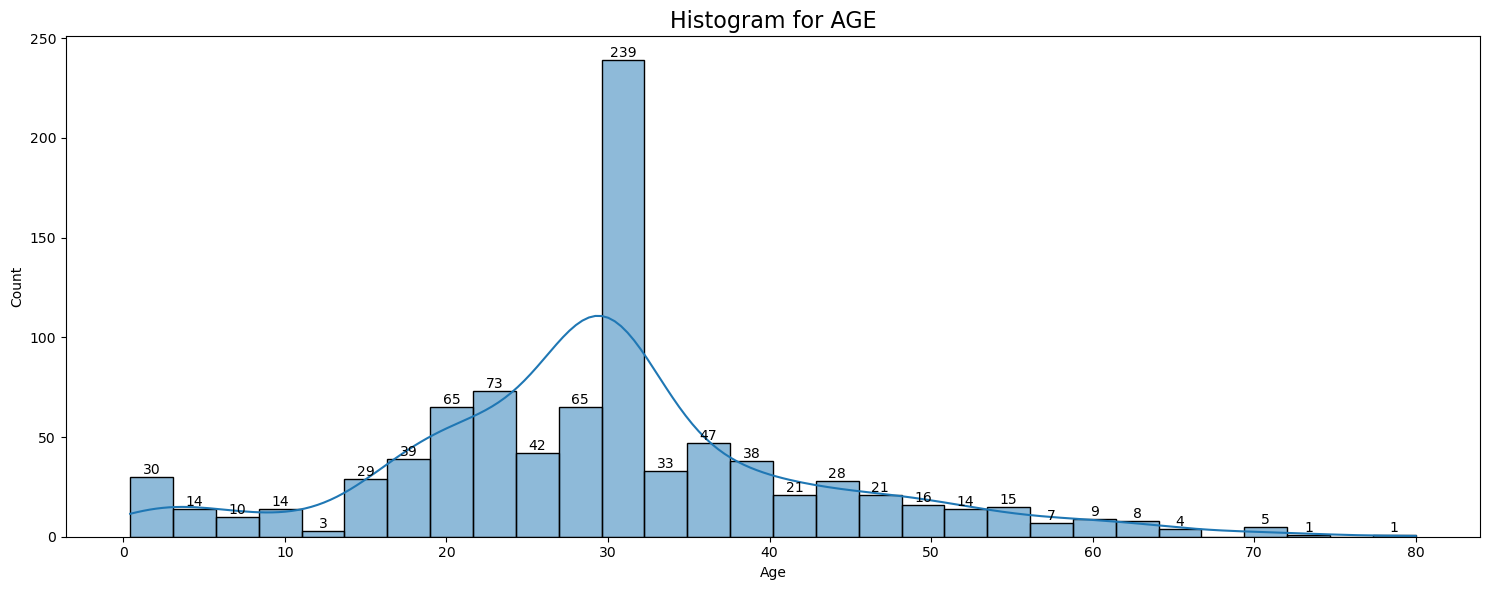

In [19]:
temp = df.select_dtypes(include = "number").columns.tolist()
print(f"""Choose one option :  
{", ".join(map(lambda x : str(x),temp))} """)
print()
inp = input("Enter the option here : ")
print()

kde_ = int(input("If you want KDE included type 1 for \"Yes\" or 0 for \"No\" : "))
print()
plt.figure(figsize = (15,6))
ax = sns.histplot(x = df[inp],
            kde = kde_,
            bins = 30
            )
for bar in ax.patches:
    height = bar.get_height()
    if(height > 0):
        ax.annotate(f"{int(height)}",
                   xy = (bar.get_x() + bar.get_width()/2,height),
                   ha = "center",
                   va = "bottom")

plt.title(f"Histogram for {inp.upper()}",fontdict ={"fontsize":16})
plt.tight_layout()
plt.show()

#### The histogram for the variables shows the distribution of the data is not in normal distribution, mostly skewed
#### we can log transform before feeding to the model (Especially linear model)

### Box Plots

Numerical columns :  
Age, SibSp, Parch, Fare 

Categorical columns :  
PassengerId, Survived, Pclass, Name, Sex, Ticket, Embarked, cabin code 

If you wish to view with categorical type 1 : 


Enter the option :  1
Enter the Numerical option :  Age


Enter any categorical column :  Sex


Enter the color name :  orchid


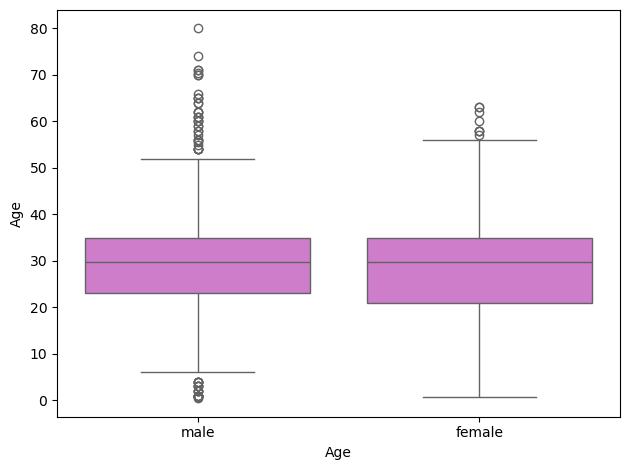

In [20]:
temp = df.select_dtypes(include = "number").columns.tolist()
print(f"""Numerical columns :  
{", ".join(map(lambda x : str(x),temp))} """)
print()
temp = df.select_dtypes(exclude = "number").columns.tolist()
print(f"""Categorical columns :  
{", ".join(map(lambda x : str(x),temp))} """)
print()
print("If you wish to view with categorical type 1 : ")
view = 0
view = int(input("Enter the option : "))
if(view != 1):
    inp_x = input("Enter the Numerical option : ")
    print()
    col = input("Enter the color name : ")
    print()
    sns.boxplot(df[inp_x],color = col)
    plt.xlabel(inp)
    plt.tight_layout()
    plt.show()
else:
    inp_x = input("Enter the Numerical option : ")
    print()
    inp_y = input("Enter any categorical column : ")
    print()
    col = input("Enter the color name : ")
    print()
    sns.boxplot(df,x = inp_y,y=inp_x,color = col)
    plt.xlabel(inp)
    plt.tight_layout()
    plt.show()

#### Certainly there are outliers, but they meant something we cannot cap them

## Bar Chart

Numerical column are : 
Age, SibSp, Parch, Fare

Categorical column are : 
PassengerId, Survived, Pclass, Name, Sex, Ticket, Embarked, cabin code



Enter the numerical column :  Age
Enter the catgorical column :  cabin code
Enter the Hue (either categorical column  or "NONE") :  none
Enter a color palette :  icefire


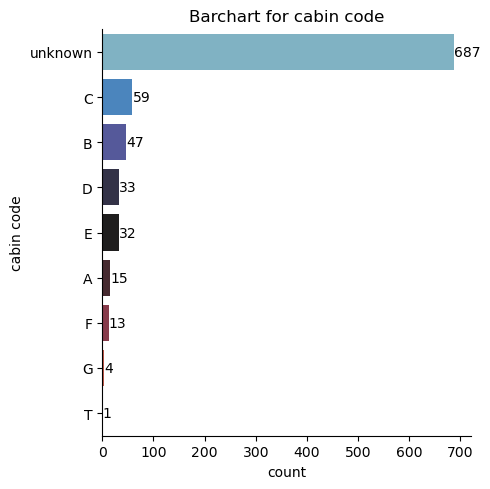

In [22]:
print("Numerical column are : ")
temp = df.select_dtypes(include = "number")
print(", ".join(map(lambda x : str(x),temp))+"\n")
print("Categorical column are : ")
temp = df.select_dtypes(exclude = "number")
print(", ".join(map(lambda x : str(x),temp))+"\n")
inp = input('Enter the numerical column : ')
cat = input("Enter the catgorical column : ")
hue = input("Enter the Hue (either categorical column  or \"NONE\") : ")
pal = input("Enter a color palette : ")
if(hue.lower() == "none" ):
    hue_ = cat
    df_bar = df[cat].value_counts().rename_axis(cat).reset_index(name = "count")
    df_bar = df_bar.sort_values(by = "count",ascending = False)
    df_bar[cat] = pd.Categorical(df_bar[cat],categories = df_bar[cat].drop_duplicates(),ordered = True)        #important 

    fg = sns.catplot(df_bar,x = "count",
           y = cat,
           kind = "bar",
           hue = hue_,
           palette = pal,
           errorbar = None)
    ax = fg.ax
    for bar in ax.patches:
        ax.annotate(f"{int(bar.get_width())}",
               xy = (bar.get_width(),bar.get_y()+bar.get_height()/2),
               ha = "left",
               va = "center")
        plt.title(f"Barchart for {cat}")
    
    plt.tight_layout()
    plt.show()
else:

    df_ = df.groupby([cat,hue],as_index = False)[inp].count()
    fg = sns.catplot(df_,x = df_[inp],
            y = df_[cat],
            hue = df_[hue],
            kind = "bar",
            errorbar = None,
            palette = pal)
    ax = fg.ax
    for bar in ax.patches:
        ax.annotate(f"{int(bar.get_width())}",
               xy = (bar.get_width(),bar.get_y() + (bar.get_height())/2),
               ha = "left",
               va = "center")
    plt.xlabel("count")
    fg._legend.set_bbox_to_anchor((1.1,0.5))
    plt.tight_layout()
    plt.show()

## Pairplot

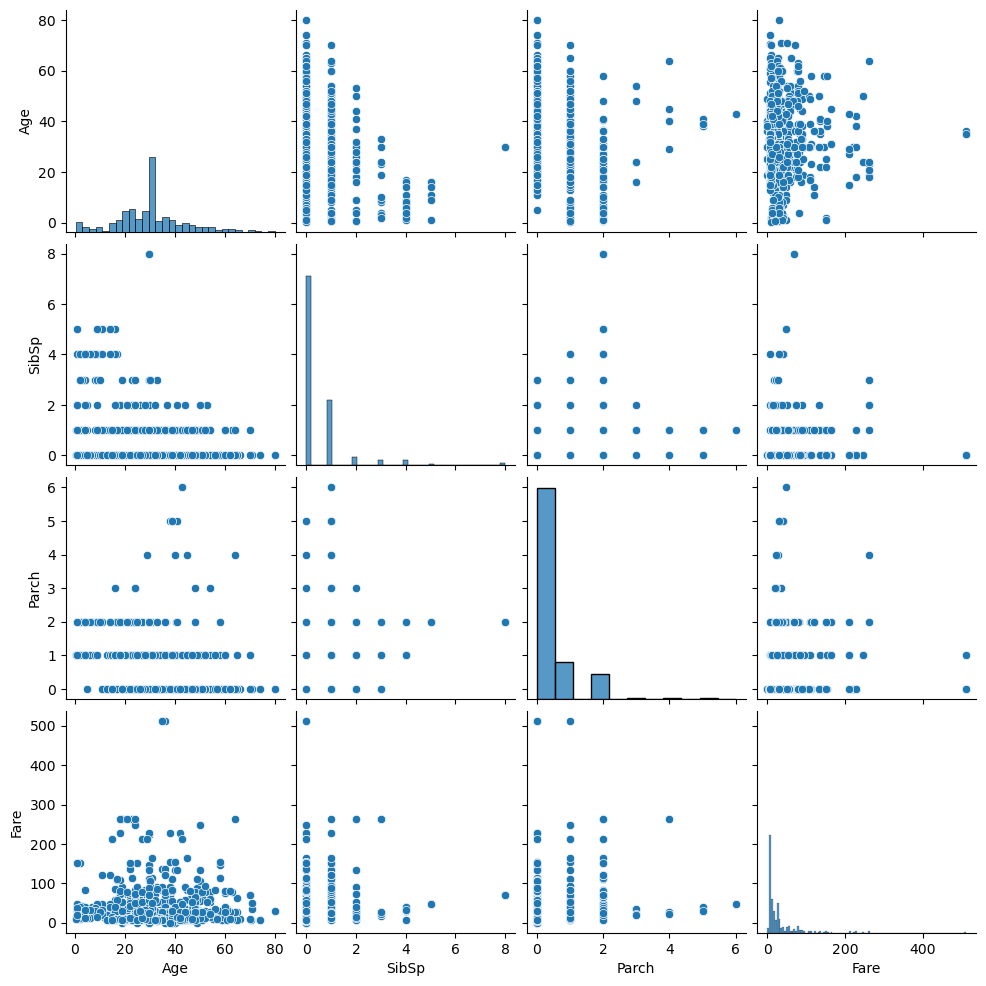

In [23]:
sns.pairplot(df)
plt.show()

## Correlation

In [24]:
corr = df.corr(numeric_only=True)
corr

,Age,SibSp,Parch,Fare
Age,1.000000,-0.232625,-0.179191,0.091566
SibSp,-0.232625,1.000000,0.414838,0.159651
Parch,-0.179191,0.414838,1.000000,0.216225
Fare,0.091566,0.159651,0.216225,1.000000


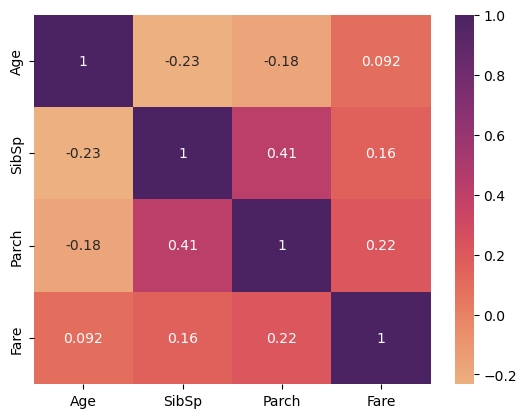

In [25]:
sns.heatmap(corr,annot = True,cmap = "flare")
plt.show()

## Preprocessing

In [26]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,cabin code
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,unknown
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,unknown
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,unknown


#### Using a regex operation to extract useful feature from Name like taking title

In [27]:
df["title"] = df["Name"].str.extract(r',\s*([^\.]*)\.',expand = False)

In [28]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,cabin code,title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,unknown,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,unknown,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,unknown,Mr


In [29]:
target = df[["Survived"]]

In [30]:
temp = df.drop(columns = ["PassengerId","Survived","Name","Ticket"])
temp

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,cabin code,title
0,3,male,22.000000,1,0,7.2500,S,unknown,Mr
1,1,female,38.000000,1,0,71.2833,C,C,Mrs
2,3,female,26.000000,0,0,7.9250,S,unknown,Miss
3,1,female,35.000000,1,0,53.1000,S,C,Mrs
4,3,male,35.000000,0,0,8.0500,S,unknown,Mr
...,...,...,...,...,...,...,...,...,...
886,2,male,27.000000,0,0,13.0000,S,unknown,Rev
887,1,female,19.000000,0,0,30.0000,S,B,Miss
888,3,female,29.699118,1,2,23.4500,S,unknown,Miss
889,1,male,26.000000,0,0,30.0000,C,C,Mr


In [31]:
temp.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,cabin code,title
0,3,male,22.0,1,0,7.2500,S,unknown,Mr
1,1,female,38.0,1,0,71.2833,C,C,Mrs
2,3,female,26.0,0,0,7.9250,S,unknown,Miss
3,1,female,35.0,1,0,53.1000,S,C,Mrs
4,3,male,35.0,0,0,8.0500,S,unknown,Mr


In [32]:
temp_cat = temp.drop(columns = ["Age","Fare","SibSp","Parch"])

In [33]:
temp_cat.columns

Index(['Pclass', 'Sex', 'Embarked', 'cabin code', 'title'], dtype='object')

### import one hot encoder

In [34]:
from sklearn.preprocessing import OneHotEncoder


In [35]:
encoder = OneHotEncoder(drop = "first",handle_unknown = "ignore",sparse_output = False)

In [36]:
encoder.fit(temp_cat[['Pclass', 'Sex', 'Embarked', 'cabin code', 'title']])

OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
feat = df.loc[:,["Age","Fare","SibSp","Parch"]]

In [39]:
scaler = StandardScaler()
feat_scaled = scaler.fit_transform(feat)
feat_scaled = pd.DataFrame(feat_scaled,columns = feat.columns)

In [40]:
features = encoder.transform(temp_cat[['Pclass', 'Sex', 'Embarked', 'cabin code', 'title']])
features = pd.DataFrame(features, columns = encoder.get_feature_names_out(temp_cat.columns))
features.head()

,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,cabin code_B,cabin code_C,cabin code_D,cabin code_E,cabin code_F,...,title_Master,title_Miss,title_Mlle,title_Mme,title_Mr,title_Mrs,title_Ms,title_Rev,title_Sir,title_the Countess
0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [41]:
features = pd.concat([features,feat_scaled],axis = 1)
features.head()

,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,cabin code_B,cabin code_C,cabin code_D,cabin code_E,cabin code_F,...,title_Mr,title_Mrs,title_Ms,title_Rev,title_Sir,title_the Countess,Age,Fare,SibSp,Parch
0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,-0.592481,-0.502445,0.432793,-0.473674
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.638789,0.786845,0.432793,-0.473674
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.284663,-0.488854,-0.474545,-0.473674
3,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.407926,0.420730,0.432793,-0.473674
4,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.407926,-0.486337,-0.474545,-0.473674


#### Here there is no requirement of train test split, because the train and test data are separated intially

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore")

In [43]:
paramgrid = {
    "penalty":["l1","l2","ElasticNet"],
    "C" : [0.01,0.1,1,2,10,100],
    "solver" :["saga"],
    "l1_ratio":[0.1,0.25,0.5,0.75,0.9]
}

In [44]:
grid = GridSearchCV(LogisticRegression(max_iter=5000),paramgrid)
grid.fit(features,target)

GridSearchCV(estimator=LogisticRegression(max_iter=5000),
             param_grid={'C': [0.01, 0.1, 1, 2, 10, 100],
                         'l1_ratio': [0.1, 0.25, 0.5, 0.75, 0.9],
                         'penalty': ['l1', 'l2', 'ElasticNet'],
                         'solver': ['saga']})

In [45]:
print(f"""estimator = {grid.best_estimator_}
Params = {grid.best_params_}
Score = {grid.best_score_}
""")

estimator = LogisticRegression(C=2, l1_ratio=0.1, max_iter=5000, penalty='l1',
                   solver='saga')
Params = {'C': 2, 'l1_ratio': 0.1, 'penalty': 'l1', 'solver': 'saga'}
Score = 0.8316552633230808



In [46]:
model = grid.best_estimator_
model

LogisticRegression(C=2, l1_ratio=0.1, max_iter=5000, penalty='l1',
                   solver='saga')

In [47]:
y_pred_train = model.predict(features)
y_pred_train

array([0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1,

## Evaluate the Model

#### import the required packages

In [48]:
from sklearn.metrics import classification_report, confusion_matrix

#### we know "target" variable and also the model predicted variable which is "y_pred_result"

In [49]:
print(classification_report(target,y_pred_train))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87       549
           1       0.80      0.77      0.78       342

    accuracy                           0.84       891
   macro avg       0.83      0.82      0.83       891
weighted avg       0.84      0.84      0.84       891



In [50]:
cm = confusion_matrix(target,y_pred_train)
print(cm)

[[483  66]
 [ 79 263]]


### ROC - AUC Curve 

#### import the required packages

In [51]:
from sklearn.metrics import roc_auc_score,roc_curve

In [52]:
fpr, tpr, threshold = roc_curve(target,y_pred_train)
print(f"""ROC - AUC Score : {roc_auc_score(target,y_pred_train)}""")

ROC - AUC Score : 0.8243936343591218


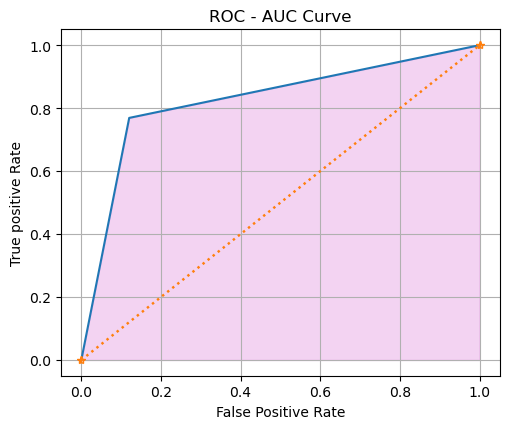

In [53]:
plt.figure(figsize  =(5,4))
plt.plot(fpr,tpr)
plt.plot([0,1],linestyle = "dotted",
        linewidth = 1.75,
         marker = "*",
         fillstyle = "left",
         label = "line")
plt.fill_between(fpr,tpr,color = "orchid",alpha = 0.3)
plt.tight_layout()
plt.grid(visible=True)
plt.xlabel("False Positive Rate")
plt.ylabel("True positive Rate")
plt.title("ROC - AUC Curve")
plt.show()

## Interpretation

In [54]:
beta_df = pd.DataFrame(model.coef_[0], index=features.columns, columns=['Beta'])
beta_df = beta_df.reset_index(names = "features")
beta_df.head()

,features,Beta
0,Pclass_2,-0.207240
1,Pclass_3,-1.247612
2,Sex_male,-2.316220
3,Embarked_Q,-0.027819
4,Embarked_S,-0.440666


In [55]:
intercept = {"features" : "intercept",
      "Beta": model.intercept_}
intercept = pd.DataFrame(intercept)
beta_df = pd.concat([intercept,beta_df],ignore_index=True)
beta_df.drop_duplicates(inplace = True)
beta_df.head()

,features,Beta
0,intercept,2.568465
1,Pclass_2,-0.207240
2,Pclass_3,-1.247612
3,Sex_male,-2.316220
4,Embarked_Q,-0.027819


In [56]:
beta_df["e_log values"] = beta_df["Beta"].apply(lambda x:np.exp(x))
beta_df

,features,Beta,e_log values
0,intercept,2.568465,13.045783
1,Pclass_2,-0.207240,0.812825
2,Pclass_3,-1.247612,0.287190
3,Sex_male,-2.316220,0.098646
4,Embarked_Q,-0.027819,0.972564
5,Embarked_S,-0.440666,0.643608
6,cabin code_B,0.046287,1.047375
7,cabin code_C,-0.193871,0.823764
8,cabin code_D,0.654088,1.923388
9,cabin code_E,1.007486,2.738707


### Baes in the above data frame we can say 
#### 1. For SibSp , for each sibling/spouse i/ncrease in number the survival chance drops by 42%(1-0.58). because the coefficient is less than 1.
#### 2. Similarly for parch. if you increase in number chances of survival drops by 30 percent
#### 3. For pclass_2 survival chance will be less than pclass_1 and better than pclass_3, similar for the rest of the classes.
#### 4. For title Master, we can say the survival chance are like 13 times when compared to other titles
#### 5. Fare ofcourse, you pay high, chances for survival will be high, with increase in prices you increase you survival chances by 1.24 times (say life boats)
#### 6. Age in reverse manner, older gets less priortised, younger will be high

### Significance of features

#### We can see Title of Master, Pclass 3 and Sex_male is having the high impact because of their coefficients
#### Female survives more than men, so that coefficent for the men feature exists in negative
#### Same for the Pclass 3 , lower classes survival chances are compared to other classes
#### Most of the features coefficients are zero making the features insignificant like title's, cabin code_F

## Testing Data

#### Load the dataset

In [59]:
df_test = pd.read_csv(r"C:\Users\lrban\Desktop\BTR\DATA SCIENCE\Assignments\Logistic Regression\Titanic_test.csv")
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


### Similar steps to the test data, what training data set has gone through

In [60]:
df_test["cabin code"] = df_test["Cabin"].str[0]
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,cabin code
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,NaN
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,NaN
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,NaN
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,NaN
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,NaN


In [61]:
df_test = df_test.drop(columns = "Cabin")
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,cabin code
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q,NaN
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S,NaN
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q,NaN
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S,NaN
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S,NaN


In [62]:
df_test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Embarked         0
cabin code     327
dtype: int64

#### Filling the null values
#### Age, Fare - mean, Cabin Code - mostly Nan so with "Unknown"
#### The mean values will be fromtrain data set

In [63]:
df_test["Fare"].fillna(df["Fare"].mean(),inplace = True)
df_test["Age"].fillna(df["Age"].mean(),inplace = True)
df_test["cabin code"].fillna("Unknown",inplace = True)


In [64]:
df_test.isnull().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
cabin code     0
dtype: int64

#### Extracting title and creating a new column, Also drop the name and ticket column

In [65]:
df_test["title"] = df_test["Name"].str.extract(r',\s*([^\.]+)\.')
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,cabin code,title
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q,Unknown,Mr
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S,Unknown,Mrs
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q,Unknown,Mr
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S,Unknown,Mr
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S,Unknown,Mrs


In [66]:
df_test = df_test.drop(columns = ["Name","Ticket","PassengerId"])

#### Transforming the categorical to numerical

In [67]:
df_test_feat = df_test.loc[:,["Age","Fare","SibSp","Parch"]]
df_test_feat_ = scaler.transform(df_test_feat)
df_test_feat = pd.DataFrame(df_test_feat_,columns = df_test_feat.columns)
df_test_feat.head()

,Age,Fare,SibSp,Parch
0,0.369449,-0.490783,-0.474545,-0.473674
1,1.331378,-0.507479,0.432793,-0.473674
2,2.485693,-0.453367,-0.474545,-0.473674
3,-0.207709,-0.474005,-0.474545,-0.473674
4,-0.592481,-0.401017,0.432793,0.767630


In [68]:
df_test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,cabin code,title
0,3,male,34.5,0,0,7.8292,Q,Unknown,Mr
1,3,female,47.0,1,0,7.0000,S,Unknown,Mrs
2,2,male,62.0,0,0,9.6875,Q,Unknown,Mr
3,3,male,27.0,0,0,8.6625,S,Unknown,Mr
4,3,female,22.0,1,1,12.2875,S,Unknown,Mrs


In [69]:
temp_cat = df_test.drop(columns = ["Age","Fare","SibSp","Parch"])
temp_cat.head()

,Pclass,Sex,Embarked,cabin code,title
0,3,male,Q,Unknown,Mr
1,3,female,S,Unknown,Mrs
2,2,male,Q,Unknown,Mr
3,3,male,S,Unknown,Mr
4,3,female,S,Unknown,Mrs


In [70]:
features = encoder.transform(temp_cat)
features.shape

(418, 29)

In [71]:
features = pd.DataFrame(features,columns = encoder.get_feature_names_out(temp_cat.columns))
features.head()

,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,cabin code_B,cabin code_C,cabin code_D,cabin code_E,cabin code_F,...,title_Master,title_Miss,title_Mlle,title_Mme,title_Mr,title_Mrs,title_Ms,title_Rev,title_Sir,title_the Countess
0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [72]:
features = pd.concat([features,df_test_feat],axis = 1)
features.head()


,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,cabin code_B,cabin code_C,cabin code_D,cabin code_E,cabin code_F,...,title_Mr,title_Mrs,title_Ms,title_Rev,title_Sir,title_the Countess,Age,Fare,SibSp,Parch
0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.369449,-0.490783,-0.474545,-0.473674
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.331378,-0.507479,0.432793,-0.473674
2,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,2.485693,-0.453367,-0.474545,-0.473674
3,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,-0.207709,-0.474005,-0.474545,-0.473674
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,-0.592481,-0.401017,0.432793,0.767630


#### We have our dataset ready, all we gotta do is transform the test data set to obtain the result

#### we have model ready with the best parameters

In [73]:
y_test_pred = model.predict(features)
y_test_pred

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [80]:
num_cols = temp.select_dtypes(include = "number").columns.tolist()
cat_cols = temp.select_dtypes(exclude = "number").columns.tolist()


In [82]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [85]:
num_pipe = Pipeline(steps = [("simple impute",SimpleImputer(strategy = "mean")),
                            ("scaler",StandardScaler())])
cat_pipe = Pipeline(steps = [("simple impute",SimpleImputer(strategy = "most_frequent")),
                             ("one hot",OneHotEncoder(drop = "first",handle_unknown = "ignore",sparse_output=False))])
preprocessor = ColumnTransformer(transformers = [("num",num_pipe,num_cols),
                                                ("cat",cat_pipe,cat_cols)])
pipeline = Pipeline(steps = [("preprocessor",preprocessor),
                            ("model",LogisticRegression(C = 2,l1_ratio=0.1,max_iter=5000,penalty="l1",solver = "saga"))])

In [87]:
pipeline.fit(temp,target)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simple '
                                                                   'impute',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'SibSp', 'Parch',
                                                   'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('simple '
                                                                   'impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one hot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Pclass', 'Sex', 'Embarked',
                                                   'cabin code', 'title'])])),
                ('model',
                 LogisticRegression(C=2, l1_ratio=0.1, max_iter=5000,
                                    penalty='l1', solver='saga'))])

In [88]:
y_test_pred_pipe = pipeline.predict(df_test)

In [92]:
print((y_test_pred_pipe == y_test_pred).all())

True


### Streamlit

In [101]:
import pickle
pickle.dump(pipeline,open("lr.pkl","wb"))